# F1 Race Position Predictor

Predicts F1 race finishing positions using historical race and qualifying data (2020-2025).
Trained on 2020-2024, evaluated on 2025.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import average_precision_score
from scipy.stats import kendalltau, spearmanr

## Data Fetching (Optional)

These cells fetch raw data via fastf1. They are commented out since CSVs already exist.
Uncomment and run only when fetching new race data.

In [32]:
session = fastf1.get_session(2026,"Australian Grand Prix","r")
session.load(telemetry= False, weather = False, messages = False)

results = session.results

results = results.drop(columns=["BroadcastName", "Abbreviation", "TeamColor", "HeadshotUrl", "CountryCode", "ClassifiedPosition"])
print(results.columns)
print(results.head(5))
results.to_csv('AustralianGpP.csv', index = False)

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 81
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 81)
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '16', '44', '1', '3', '87', '41', '5', '10', '31', '23', '30', '43', '55', '11', '18', '14', '77', '6', '81', '27']


Index(['DriverNumber', 'DriverId', 'TeamName', 'TeamId', 'FirstName',
       'LastName', 'FullName', 'Position', 'GridPosition', 'Q1', 'Q2', 'Q3',
       'Time', 'Status', 'Points', 'Laps'],
      dtype='object')
   DriverNumber   DriverId  TeamName    TeamId FirstName   LastName  \
63           63    russell  Mercedes  mercedes    George    Russell   
12           12  antonelli  Mercedes  mercedes      Kimi  Antonelli   
16           16    leclerc   Ferrari   ferrari   Charles    Leclerc   
44           44   hamilton   Ferrari   ferrari     Lewis   Hamilton   
1             1     norris   McLaren   mclaren     Lando     Norris   

           FullName  Position  GridPosition  Q1  Q2  Q3  \
63   George Russell       1.0           1.0 NaT NaT NaT   
12   Kimi Antonelli       2.0           2.0 NaT NaT NaT   
16  Charles Leclerc       3.0           4.0 NaT NaT NaT   
44   Lewis Hamilton       4.0           7.0 NaT NaT NaT   
1      Lando Norris       5.0           6.0 NaT NaT NaT   

     

In [33]:

# def time_to_seconds(t):
#     try:
#         return round(pd.to_timedelta(str(t)).total_seconds(), 3)
#     except:
#         return None

# def load_race_weekend(year, round_num):
#     try:
#         # Qualifying
#         quali = fastf1.get_session(year, round_num, 'Q')
#         quali.load(telemetry=False, weather=False, messages=False)
        
#         quali_df = quali.results[[
#             'DriverNumber', 'FullName', 'TeamName',
#             'Position', 'Q1', 'Q2', 'Q3'
#         ]].copy()
#         quali_df = quali_df.rename(columns={'Position': 'GridPosition'})
#         quali_df['Q1_seconds'] = quali_df['Q1'].apply(time_to_seconds)
#         quali_df['Q2_seconds'] = quali_df['Q2'].apply(time_to_seconds)
#         quali_df['Q3_seconds'] = quali_df['Q3'].apply(time_to_seconds)
#         quali_df = quali_df.drop(columns=['Q1', 'Q2', 'Q3'])

#         # Race
#         race = fastf1.get_session(year, round_num, 'R')
#         race.load(telemetry=False, weather=False, messages=False)
        
#         race_df = race.results[['FullName', 'Position', 'Status', 'Points', 'Time']].copy()
#         race_df['TimeDelta'] = race_df['Time'].apply(time_to_seconds)
#         race_df = race_df.rename(columns={'Position': 'RacePosition'})
#         race_df = race_df.drop(columns='Time')

#         # Merge
#         merged = pd.merge(quali_df, race_df, on='FullName', how='inner')
#         merged['Season'] = year
#         merged['Round'] = round_num
#         merged['EventName'] = race.event['EventName']
#         merged['FinishPosition'] = pd.to_numeric(merged['RacePosition'], errors='coerce')

#         return merged

#     except Exception as e:
#         print(f"  âœ— Round {round_num} skipped: {e}")
#         return None


# # â”€â”€ Run with resume support â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# all_seasons = []

# for year in range(2025, 2026):
#     print(f"\n{'='*40}")
#     print(f"  Loading {year}...")
#     print(f"{'='*40}")

#     season_file = f'data/f1_{year}.csv'
#     schedule = fastf1.get_event_schedule(year, include_testing=False)
#     all_rounds = list(schedule['RoundNumber'])

#     # â”€â”€ Resume logic â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
#     existing_df = None
#     completed_rounds = set()

#     if os.path.exists(season_file):
#         existing_df = pd.read_csv(season_file)
#         completed_rounds = set(existing_df['Round'].unique())
#         print(f"  âœ“ Found existing data â€” {len(completed_rounds)} rounds already loaded: {sorted(completed_rounds)}")
    
#     remaining_rounds = [r for r in all_rounds if r not in completed_rounds]

#     if not remaining_rounds:
#         print(f"  âœ“ All rounds complete â€” loading from CSV")
#         all_seasons.append(existing_df)
#         continue

#     print(f"  â†’ Rounds to fetch: {remaining_rounds}")

#     # â”€â”€ Fetch missing rounds â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
#     season_data = []
#     for round_num in remaining_rounds:
#         print(f"Loading round {round_num}...", end=' ')
#         df = load_race_weekend(year, round_num)
#         if df is not None:
#             season_data.append(df)
#             print(f"âœ“ {df['EventName'].iloc[0]}")
#         time.sleep(3)

#     # â”€â”€ Merge new data with existing and save â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
#     frames = []
#     if existing_df is not None:
#         frames.append(existing_df)
#     if season_data:
#         frames.append(pd.concat(season_data, ignore_index=True))

#     if frames:
#         year_df = pd.concat(frames, ignore_index=True)
#         year_df = year_df.sort_values('Round').reset_index(drop=True)  # keep rounds in order
#         year_df.to_csv(season_file, index=False)
#         print(f"  âœ“ Saved {len(year_df['Round'].unique())} total rounds for {year}")
#         all_seasons.append(year_df)

#     print(f"\nDone!")

In [34]:

# Load and combine all seasons
years = range(2020, 2026)  # 2020-2024
dfs = [pd.read_csv(f'data/f1_{year}.csv') for year in years]

combined = pd.concat(dfs, ignore_index=True)
combined = combined.sort_values(['Season', 'Round']).reset_index(drop=True)


combined.to_csv('data/f1_2020_2025.csv', index=False)
print(f"Combined dataset: {len(combined)} rows across {combined['Season'].nunique()} seasons")

Combined dataset: 2617 rows across 6 seasons


## Data Loading

Load the combined dataset and sort chronologically.

In [ ]:
df = pd.read_csv('data/f1_2020_2025.csv')
df = df.sort_values(['Season', 'Round']).reset_index(drop=True)
print(f"Loaded {len(df)} rows across {df['Season'].nunique()} seasons ({int(df['Season'].min())}-{int(df['Season'].max())})")

## Exploratory Data Analysis

Initial exploration of the raw data before feature engineering.
These cells use temporary copies to avoid mutating the main dataframe.

In [ ]:
# Raw feature correlation with RacePosition (before feature engineering)
_eda = df.drop(columns=['Time', 'Podium', 'Points', 'Status', 'DriverNumber'], errors='ignore')
_team_dummies = pd.get_dummies(_eda['TeamName'], prefix='Team')
_eda_numeric = pd.concat([_eda.drop(columns=['TeamName', 'FullName', 'EventName']), _team_dummies], axis=1)

corr_matrix = _eda_numeric.corr()['RacePosition'].drop('RacePosition').sort_values()
corr_matrix.plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Raw Feature Correlation with Race Position')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

In [ ]:
sns.boxplot(data=df, x='GridPosition', y='RacePosition')
plt.title('Race Finish vs Grid Position')
plt.tight_layout()
plt.show()

In [ ]:
# Per-year team performance summary
for year in range(2020, 2025):
    _yr = pd.read_csv(f'data/f1_{year}.csv')
    stats = _yr.groupby('TeamName')['RacePosition'].agg(['mean', 'std']).sort_values('mean')
    print(f"\n{'=' * 40}")
    print(f" Team Stats for {year}")
    print(f"{'=' * 40}")
    print(stats)

In [ ]:
# Lewis Hamilton avg finish position per season (tracking decline over time)
_ham = df[df['FullName'] == 'Lewis Hamilton']
for season in sorted(_ham['Season'].unique()):
    avg = _ham[_ham['Season'] == season]['RacePosition'].mean()
    print(f"{int(season)}: avg P{avg:.1f}")

## Feature Engineering

All rolling features use `.shift(1)` before aggregation to prevent look-ahead leakage.
The model never sees the current race's data when computing features.

### Driver Rolling Features

In [ ]:
# Rolling averages capture recent form — shift(1) ensures no leakage
df['driver_rolling_avg_3'] = (
    df.groupby('FullName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)
df['driver_rolling_avg_5'] = (
    df.groupby('FullName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)
df['driver_rolling_std_5'] = (
    df.groupby('FullName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).std())
)
df['driver_last_finish'] = (
    df.groupby('FullName')['RacePosition']
    .transform(lambda x: x.shift(1))
)
print("Added: driver_rolling_avg_3, driver_rolling_avg_5, driver_rolling_std_5, driver_last_finish")

### Team Rolling Features

In [ ]:
df['team_rolling_avg_5'] = (
    df.groupby('TeamName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)
df['team_rolling_avg_3'] = (
    df.groupby('TeamName')['RacePosition']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)
print("Added: team_rolling_avg_5, team_rolling_avg_3")

### Qualifying Features

In [ ]:
# Best qualifying time (Q3 > Q2 > Q1 fallback) and delta to teammate
df['best_q_time'] = df['Q3_seconds'].fillna(df['Q2_seconds']).fillna(df['Q1_seconds'])
teammate_avg = df.groupby(['Season', 'Round', 'TeamName'])['best_q_time'].transform('mean')
df['quali_delta_to_teammate'] = df['best_q_time'] - teammate_avg
print("Added: best_q_time, quali_delta_to_teammate")

### Track-Specific Driver History

In [ ]:
# Historical avg finish at this specific circuit from all prior seasons
# Validated via Spearman correlation (rho=0.311, p<1e-13) — moderate but real signal
df = df.sort_values(['FullName', 'EventName', 'Season', 'Round'])
df['driver_track_history_avg'] = (
    df.groupby(['FullName', 'EventName'])['RacePosition']
    .transform(lambda x: x.shift(1).expanding(min_periods=1).mean())
)
# Fill NaN (first appearance at a circuit) with driver's overall rolling avg
df['driver_track_history_avg'] = df['driver_track_history_avg'].fillna(df['driver_rolling_avg_5'])
print(f"Added: driver_track_history_avg (NaN remaining: {df['driver_track_history_avg'].isna().sum()})")

### Data Cleanup & Encoding

Rename RacePosition to FinishPosition, engineer TimeDelta rolling features,
drop leakage columns, and one-hot encode categoricals.

In [ ]:
# Rename and drop redundant columns
df = df.drop(columns=['DriverNumber'], errors='ignore')
df = df.rename(columns={'RacePosition': 'FinishPosition'})

# TimeDelta: set winner to 0, fill DNFs with 300s proxy
df = df.sort_values(['FullName', 'Season', 'Round'])
df.loc[df['FinishPosition'] == 1, 'TimeDelta'] = 0
df['TimeDelta'] = df['TimeDelta'].fillna(300)

# Rolling TimeDelta features
df['driver_rolling_avg_timedelta_3'] = (
    df.groupby('FullName')['TimeDelta']
    .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
)
df['driver_rolling_avg_timedelta_5'] = (
    df.groupby('FullName')['TimeDelta']
    .transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
)
# Fill NaN with training-set mean only (no leakage from 2025)
train_timedelta_mean = df[df['Season'] <= 2024]['TimeDelta'].mean()
df['driver_rolling_avg_timedelta_3'] = df['driver_rolling_avg_timedelta_3'].fillna(train_timedelta_mean)
df['driver_rolling_avg_timedelta_5'] = df['driver_rolling_avg_timedelta_5'].fillna(train_timedelta_mean)

# Drop leakage columns
leakage = ['Points', 'TimeDelta', 'TimeDetla', 'Podium', 'Status', 'Time']
df = df.drop(columns=leakage, errors='ignore')

# Save reference copy before encoding (needed for evaluation)
df_ref = df[['Season', 'Round', 'EventName', 'FullName', 'FinishPosition']].copy()

# One-hot encode categoricals
teamDummy = pd.get_dummies(df['TeamName'], prefix='Team')
driverDummy = pd.get_dummies(df['FullName'], prefix='Driver')
eventDummy = pd.get_dummies(df['EventName'], prefix='Event')
df = df.drop(columns=['TeamName', 'FullName', 'EventName'])
df = pd.concat([df, teamDummy, driverDummy, eventDummy], axis=1)

# Drop rows missing qualifying data, then drop intermediate columns
df = df.dropna(subset=['best_q_time'])
df = df.drop(columns=['driver_rolling_avg_timedelta_3', 'team_rolling_avg_3',
                       'Q1_seconds', 'Q2_seconds', 'Q3_seconds', 'best_q_time'])

print(f"Final shape: {df.shape}")

## Feature Analysis

Correlation analysis on the engineered features after encoding.

In [ ]:
# Which drivers/teams correlate most with finish position?
dummy_cols = [col for col in df.columns if col.startswith('Driver_') or col.startswith('Team_')]
dummy_corr = df[dummy_cols + ['FinishPosition']].corr()['FinishPosition'].drop('FinishPosition')

print("Most positive correlation (worse finishers):")
print(dummy_corr.sort_values(ascending=False).head(10))
print("\nMost negative correlation (better finishers):")
print(dummy_corr.sort_values(ascending=True).head(10))

In [ ]:
# Numeric feature correlation heatmap
numeric_cols = ['GridPosition', 'quali_delta_to_teammate',
                'driver_rolling_avg_5', 'driver_rolling_std_5', 'driver_last_finish',
                'team_rolling_avg_5',
                'driver_rolling_avg_timedelta_5', 'driver_track_history_avg', 'FinishPosition']
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Track Analysis

Self-contained analyses using fresh data loads (2020-2024 only).
These do not affect the model pipeline.

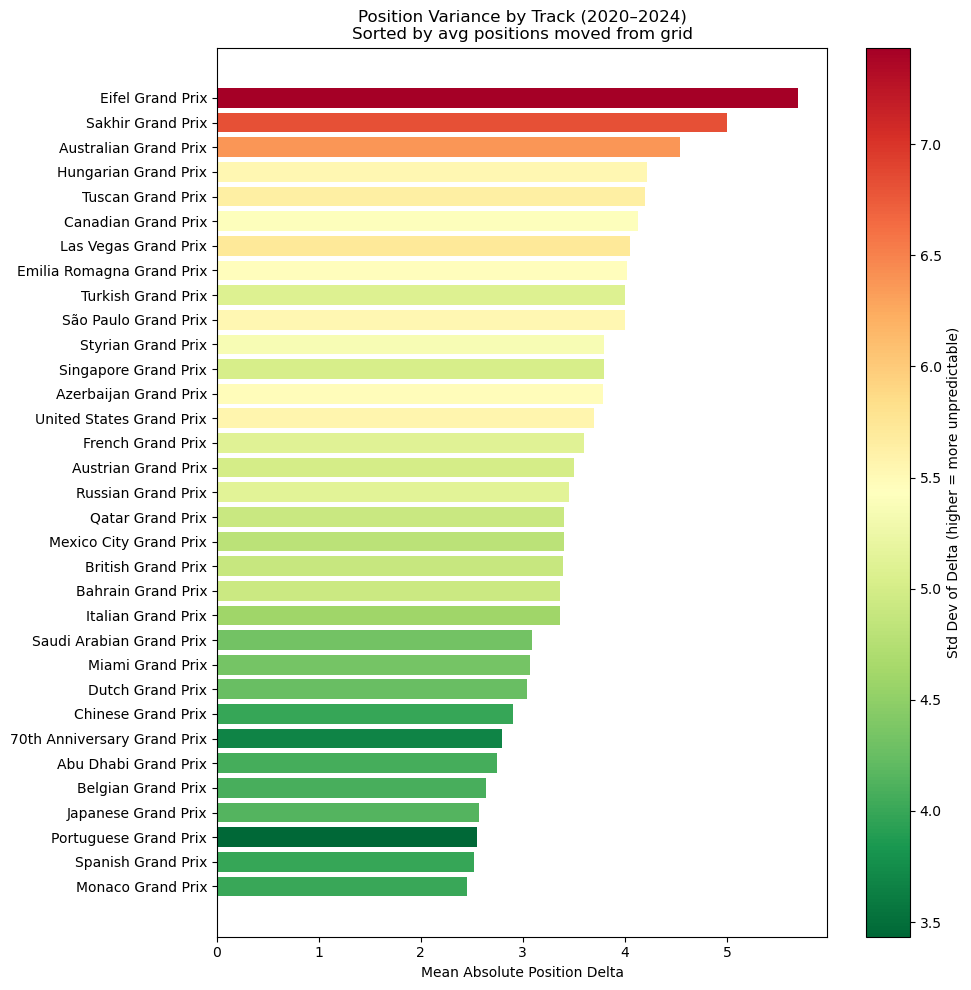

                  EventName  mean_abs_delta  std_delta  median_delta  avg_gained  avg_lost
           Eifel Grand Prix        5.700000   7.433919           1.5    4.750000 -8.142857
          Sakhir Grand Prix        5.000000   6.821020           1.5    3.846154 -7.142857
      Australian Grand Prix        4.542373   6.373436           1.0    3.621622 -7.052632
       Hungarian Grand Prix        4.220000   5.528622           0.0    4.906977 -4.395833
          Tuscan Grand Prix        4.200000   5.638215           1.0    3.818182 -7.000000
        Canadian Grand Prix        4.133333   5.411851           1.0    3.757576 -5.391304
       Las Vegas Grand Prix        4.050000   5.724442           0.0    4.764706 -5.062500
  Emilia Romagna Grand Prix        4.025000   5.451745           1.0    3.926829 -5.366667
       São Paulo Grand Prix        4.000000   5.532413           1.0    3.809524 -5.333333
         Turkish Grand Prix        4.000000   5.088952           0.5    4.000000 -5.000000

In [52]:
# === EDA: Position Variance by Track (2020–2024) ===
import matplotlib.cm as cm

_raw = pd.read_csv('data/f1_2020_2025.csv')
_raw = _raw[_raw['Season'] <= 2024].copy()

# Positive delta = gained positions, negative = lost
_raw['positions_delta'] = _raw['GridPosition'] - _raw['RacePosition']

def _avg_gained(x):
    gains = x[x > 0]
    return gains.mean() if len(gains) > 0 else 0.0

def _avg_lost(x):
    losses = x[x < 0]
    return losses.mean() if len(losses) > 0 else 0.0

track_stats = _raw.groupby('EventName')['positions_delta'].agg(
    mean_abs_delta=lambda x: x.abs().mean(),
    std_delta='std',
    median_delta='median',
    avg_gained=_avg_gained,
    avg_lost=_avg_lost
).reset_index().sort_values('mean_abs_delta', ascending=True)

# Horizontal bar chart colored by std deviation
fig, ax = plt.subplots(figsize=(10, 10))
norm = plt.Normalize(track_stats['std_delta'].min(), track_stats['std_delta'].max())
colors = cm.RdYlGn_r(norm(track_stats['std_delta']))
ax.barh(track_stats['EventName'], track_stats['mean_abs_delta'], color=colors)
sm = plt.cm.ScalarMappable(cmap='RdYlGn_r', norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Std Dev of Delta (higher = more unpredictable)')
ax.set_xlabel('Mean Absolute Position Delta')
ax.set_title('Position Variance by Track (2020–2024)\nSorted by avg positions moved from grid')
plt.tight_layout()
plt.show()

print(track_stats.sort_values('mean_abs_delta', ascending=False).to_string(index=False))

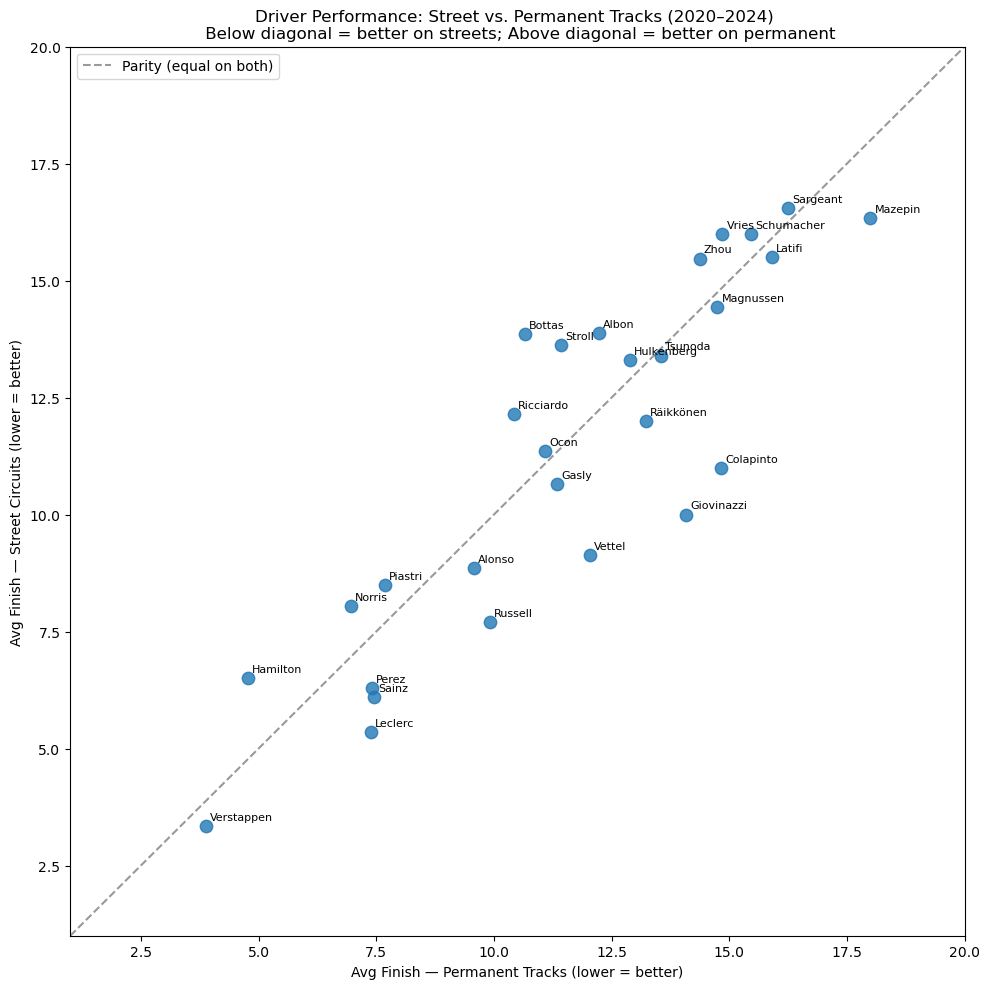

                    street_avg   perm_avg  street_count  perm_count
FullName                                                           
Max Verstappen        3.350000   3.873563            20          87
Charles Leclerc       5.350000   7.379310            20          87
Carlos Sainz          6.105263   7.448276            19          87
Sergio Perez          6.300000   7.411765            20          85
Lewis Hamilton        6.500000   4.779070            20          86
George Russell        7.700000   9.908046            20          87
Lando Norris          8.050000   6.965517            20          87
Oscar Piastri         8.500000   7.676471            12          34
Fernando Alonso       8.850000   9.571429            20          70
Sebastian Vettel      9.142857  12.038462             7          52
Antonio Giovinazzi   10.000000  14.083333             3          36
Pierre Gasly         10.650000  11.344828            20          87
Franco Colapinto     11.000000  14.833333       

In [53]:
# === EDA: Driver Performance — Street vs. Permanent Tracks (2020–2024) ===

_street_circuits = {
    'Monaco Grand Prix',
    'Singapore Grand Prix',
    'Azerbaijan Grand Prix',
    'Las Vegas Grand Prix',
    'Miami Grand Prix',
    'Saudi Arabian Grand Prix',
}

_raw2 = pd.read_csv('data/f1_2020_2025.csv')
_raw2 = _raw2[_raw2['Season'] <= 2024].copy()
_raw2['track_type'] = _raw2['EventName'].apply(
    lambda e: 'Street' if e in _street_circuits else 'Permanent'
)

_street_avg = (
    _raw2[_raw2['track_type'] == 'Street']
    .groupby('FullName')['RacePosition']
    .agg(street_avg='mean', street_count='count')
)
_perm_avg = (
    _raw2[_raw2['track_type'] == 'Permanent']
    .groupby('FullName')['RacePosition']
    .agg(perm_avg='mean', perm_count='count')
)

_driver_stats = _street_avg.join(_perm_avg, how='inner')
_driver_stats = _driver_stats[
    (_driver_stats['street_count'] >= 3) & (_driver_stats['perm_count'] >= 3)
]

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(_driver_stats['perm_avg'], _driver_stats['street_avg'], s=80, alpha=0.8)

for name, row in _driver_stats.iterrows():
    ax.annotate(
        name.split()[-1],
        (row['perm_avg'], row['street_avg']),
        fontsize=8, ha='left', va='bottom',
        xytext=(3, 3), textcoords='offset points'
    )

ax.plot([1, 20], [1, 20], 'k--', alpha=0.4, label='Parity (equal on both)')
ax.set_xlim(1, 20)
ax.set_ylim(1, 20)
ax.set_xlabel('Avg Finish — Permanent Tracks (lower = better)')
ax.set_ylabel('Avg Finish — Street Circuits (lower = better)')
ax.set_title('Driver Performance: Street vs. Permanent Tracks (2020–2024) \n Below diagonal = better on streets; Above diagonal = better on permanent')
ax.legend()
plt.tight_layout()
plt.show()

print(_driver_stats[['street_avg', 'perm_avg', 'street_count', 'perm_count']].sort_values('street_avg').to_string())

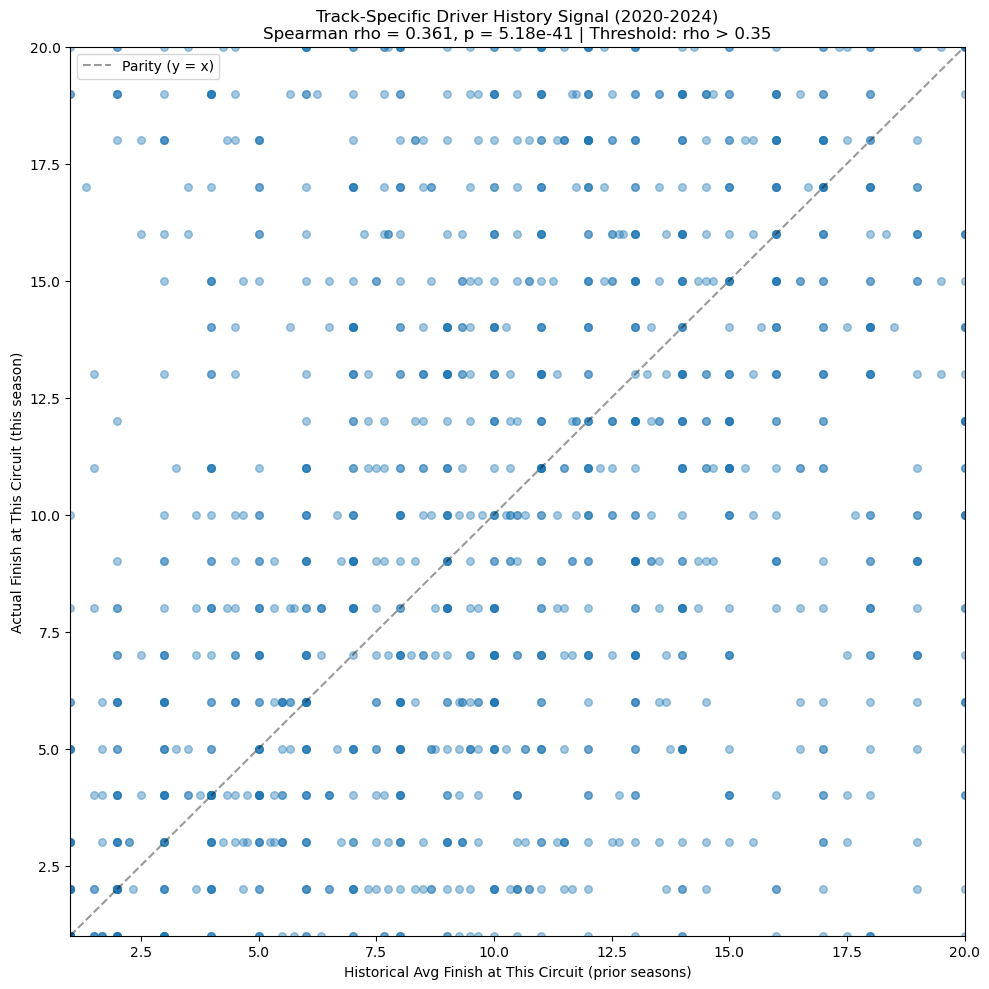

Pooled Spearman rho: 0.361  (p-value: 5.18e-41)
Number of driver-circuit-season pairs: 1287

Signal assessment: WORTH ADDING as feature


In [54]:
# === EDA: Track-Specific Driver History Signal (2020–2024) ===
from scipy.stats import spearmanr

_raw3 = pd.read_csv('data/f1_2020_2025.csv')
_raw3 = _raw3[_raw3['Season'] <= 2024].copy()

# For each driver x circuit x season, compute historical avg finish from prior seasons
_pairs = []
for (driver, circuit), group in _raw3.groupby(['FullName', 'EventName']):
    group = group.sort_values('Season')
    seasons = group['Season'].values
    finishes = group['RacePosition'].values
    for i in range(1, len(seasons)):
        historical_avg = finishes[:i].mean()
        actual_finish = finishes[i]
        if not np.isnan(historical_avg) and not np.isnan(actual_finish):
            _pairs.append({
                'driver': driver,
                'circuit': circuit,
                'season': seasons[i],
                'historical_avg': historical_avg,
                'actual_finish': actual_finish,
            })

_pairs_df = pd.DataFrame(_pairs)

# Pooled Spearman correlation
_rho, _pval = spearmanr(_pairs_df['historical_avg'], _pairs_df['actual_finish'])

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(_pairs_df['historical_avg'], _pairs_df['actual_finish'], s=30, alpha=0.4)
ax.plot([1, 20], [1, 20], 'k--', alpha=0.4, label='Parity (y = x)')
ax.set_xlim(1, 20)
ax.set_ylim(1, 20)
ax.set_xlabel('Historical Avg Finish at This Circuit (prior seasons)')
ax.set_ylabel('Actual Finish at This Circuit (this season)')
ax.set_title(f'Track-Specific Driver History Signal (2020-2024)\nSpearman rho = {_rho:.3f}, p = {_pval:.2e} | Threshold: rho > 0.35')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Pooled Spearman rho: {_rho:.3f}  (p-value: {_pval:.2e})')
print(f'Number of driver-circuit-season pairs: {len(_pairs_df)}')
print(f'\nSignal assessment: {"WORTH ADDING as feature" if _rho > 0.35 else "Too weak to add"}')

## Model Training

Random Forest Regressor trained on 2020-2024, evaluated on 2025.
Temporal split prevents data leakage from future seasons.

In [ ]:
# Temporal train/eval split — no random splitting
df_train = df[df['Season'] <= 2024]
df_eval = df[df['Season'] == 2025]

X_train = df_train.drop(columns=['FinishPosition', 'Season', 'Round'])
y_train = df_train['FinishPosition']
X_val = df_eval.drop(columns=['FinishPosition', 'Season', 'Round'])
y_val = df_eval['FinishPosition']

# Drop rows with NaN target
mask = y_train.notna()
X_train = X_train[mask]
y_train = y_train[mask]

print(f"Training: {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Validation: {X_val.shape[0]} rows")

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100, max_depth=None, max_features='sqrt',
    min_samples_split=2, random_state=42
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)
df_eval_ref = df_ref.loc[X_val.index].copy()
df_eval_ref['Predicted'] = y_pred
df_eval_ref['Predicted_Rank'] = df_eval_ref.groupby('EventName')['Predicted'].rank(method='first').astype(int)

# Save predictions
df_eval_ref.sort_values(['Round', 'Predicted_Rank']).to_csv('f1_2025_predictions.csv', index=False)
print("Model trained. Predictions saved to f1_2025_predictions.csv")

## Evaluation

Per-race metrics: Kendall's Tau (ranking quality), MAE (positions off),
AP@5 (top-5 ordering), Top-5 Precision (top-5 identification).

In [ ]:
tau_scores = {}
mae_scores = {}
ap5_scores = {}
top5_scores = {}

for race in df_eval_ref['EventName'].unique():
    race_df = df_eval_ref[df_eval_ref['EventName'] == race].dropna(subset=['FinishPosition'])

    tau, _ = kendalltau(race_df['FinishPosition'], race_df['Predicted_Rank'])
    mae = (race_df['FinishPosition'] - race_df['Predicted_Rank']).abs().mean()

    actual_top5 = (race_df['FinishPosition'] <= 5).astype(int)
    ap5 = average_precision_score(actual_top5, -race_df['Predicted_Rank'])

    predicted_top5_names = set(race_df.nsmallest(5, 'Predicted_Rank')['FullName'])
    actual_top5_names = set(race_df.nsmallest(5, 'FinishPosition')['FullName'])
    top5_precision = len(predicted_top5_names & actual_top5_names) / 5

    tau_scores[race] = round(tau, 3)
    mae_scores[race] = round(mae, 3)
    ap5_scores[race] = round(ap5, 3)
    top5_scores[race] = round(top5_precision, 3)

print(f"Mean Kendall's Tau:   {np.mean(list(tau_scores.values())):.3f}")
print(f"Mean MAE:             {np.mean(list(mae_scores.values())):.3f} positions")
print(f"Mean AP@5:            {np.mean(list(ap5_scores.values())):.3f}")
print(f"Mean Top-5 Precision: {np.mean(list(top5_scores.values())):.3f}")

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(df_eval_ref['Predicted_Rank'], df_eval_ref['FinishPosition'],
           alpha=0.3, edgecolors='steelblue', facecolors='steelblue', s=40)
ax.plot([1, 20], [1, 20], color='red', linestyle='--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Predicted Rank')
ax.set_ylabel('Actual Finish Position')
ax.set_title(f"Predicted vs Actual (2025) | Tau: {np.mean(list(tau_scores.values())):.3f} | MAE: {np.mean(list(mae_scores.values())):.3f}")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Per-race Kendall's Tau bar chart
races_sorted = sorted(tau_scores.items(), key=lambda x: x[1], reverse=True)
race_names = [r[0].replace(' Grand Prix', '') for r in races_sorted]
taus = [r[1] for r in races_sorted]
colors = ['steelblue' if t >= 0 else 'tomato' for t in taus]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(race_names, taus, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(np.mean(taus), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(taus):.3f}')
ax.set_xlabel("Kendall's Tau")
ax.set_title("Per-Race Kendall's Tau - 2025 Season")
ax.legend()
plt.tight_layout()
plt.show()